# PRIDE Performance Figures

Regenerates the four performance figures used in the manuscript's
Experimental Evaluation section (Section VII / Appendix):

  - **scalability.png**    — Total time (enc + decoy) vs. N
  - **encryption_time.png** — Encryption time (real records only) vs. N
  - **decoy_time.png**     — Decoy generation time vs. N
  - **storage.png**        — Ciphertext length (shares) vs. N

Parameters match the manuscript exactly:
  n=3, K=2, p=2^61-1, seed=40
  N ∈ {1_000, 5_000, 10_000, 50_000, 100_000}

Place this notebook in the same folder as pride_core.py and run all cells.
The four PNG files are saved in the same directory.

## Cell 1 — Imports and config

In [3]:
import os, sys, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# __file__ is undefined in Jupyter; fall back to cwd (works in both contexts)
sys.path.insert(0, str(__import__('pathlib').Path(
    globals().get('__file__', '.')).resolve().parent))

from pride_core import PRIDE, PRIDEParams, GaussianSampler, P_FIELD

# ---- Parameters matching the manuscript ----
SEED      = 40
N_THR     = 3          # threshold n
K_DECOYS  = 2          # decoys per real record
MEAN_MSG  = 1000.0
STD_MSG   = 100.0
INIT_SH   = 5          # initial shares in D

DATASET_SIZES = [1_000, 5_000, 10_000, 50_000, 100_000]

np.random.seed(SEED)
print(f"Config: n={N_THR}, K={K_DECOYS}, seed={SEED}")
print(f"Dataset sizes: {DATASET_SIZES}")

# ---- Plot style ----
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':      11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid':      True,
    'grid.alpha':     0.35,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
    'figure.dpi':     150,
})

COLOR_ENC   = '#1f77b4'   # blue
COLOR_DECOY = '#ff7f0e'   # orange
COLOR_TOTAL = '#2ca02c'   # green
COLOR_STORE = '#9467bd'   # purple

print("Plot style configured.")

Config: n=3, K=2, seed=40
Dataset sizes: [1000, 5000, 10000, 50000, 100000]
Plot style configured.


## Cell 2 — Benchmark function

In [5]:
def benchmark_N(N: int, n: int, K: int, seed: int) -> dict:
    """
    Encrypt N real records + K decoys each using PRIDE(n, K).
    Times encryption and decoy generation separately.
    Returns enc_time, decoy_time, ciphertext_length.
    """
    params  = PRIDEParams(n=n, K=K, init_shares=INIT_SH)
    system  = PRIDE(params, seed=seed)
    sampler = GaussianSampler(mean=MEAN_MSG, std=STD_MSG, seed=seed)
    ct      = system.setup()

    enc_times   = []
    decoy_times = []

    for _ in range(N):
        m = int(sampler()) % params.p

        # --- Encrypt real record ---
        t0 = time.perf_counter()
        sk_real = system.encrypt_single(ct, m)
        enc_times.append(time.perf_counter() - t0)

        # --- Generate K decoys ---
        t0 = time.perf_counter()
        for _ in range(K):
            md = int(sampler()) % params.p
            system.encrypt_single(ct, md)
        decoy_times.append(time.perf_counter() - t0)

    return {
        'N':           N,
        'enc_time':    sum(enc_times),
        'decoy_time':  sum(decoy_times),
        'total_time':  sum(enc_times) + sum(decoy_times),
        'ct_length':   ct.length,
    }

print("Benchmark function defined.")

Benchmark function defined.


## Cell 3 — Run benchmarks

N=100,000 takes roughly 3–5 minutes on a standard laptop.
Progress is printed after each size.

In [7]:
results = []

for N in DATASET_SIZES:
    t_wall = time.perf_counter()
    row = benchmark_N(N, N_THR, K_DECOYS, SEED)
    wall = time.perf_counter() - t_wall
    print(f"N={N:>7,}  enc={row['enc_time']:.3f}s  "
          f"decoy={row['decoy_time']:.3f}s  "
          f"total={row['total_time']:.3f}s  "
          f"shares={row['ct_length']:,}  "
          f"(wall {wall:.1f}s)")
    results.append(row)

Ns          = [r['N']          for r in results]
enc_times   = [r['enc_time']   for r in results]
decoy_times = [r['decoy_time'] for r in results]
total_times = [r['total_time'] for r in results]
ct_lengths  = [r['ct_length']  for r in results]

print("\nAll benchmarks complete.")

N=  1,000  enc=0.157s  decoy=0.321s  total=0.478s  shares=3,005  (wall 0.5s)
N=  5,000  enc=0.568s  decoy=1.179s  total=1.748s  shares=15,005  (wall 1.8s)
N= 10,000  enc=1.138s  decoy=2.339s  total=3.477s  shares=30,005  (wall 3.5s)
N= 50,000  enc=5.439s  decoy=11.217s  total=16.656s  shares=150,005  (wall 16.9s)
N=100,000  enc=10.704s  decoy=22.068s  total=32.772s  shares=300,005  (wall 33.2s)

All benchmarks complete.


## Cell 4 — Print table (matches Tab. enc_decoy_stats in manuscript)

In [9]:
print("\n" + "="*72)
print(f"{'N':>10}  {'Enc (s)':>10}  {'Decoy (s)':>10}  {'CT Length':>12}")
print("-"*72)
for r in results:
    print(f"{r['N']:>10,}  {r['enc_time']:>10.3f}  "
          f"{r['decoy_time']:>10.3f}  {r['ct_length']:>12,}")
print("="*72)


         N     Enc (s)   Decoy (s)     CT Length
------------------------------------------------------------------------
     1,000       0.157       0.321         3,005
     5,000       0.568       1.179        15,005
    10,000       1.138       2.339        30,005
    50,000       5.439      11.217       150,005
   100,000      10.704      22.068       300,005


## Cell 5 — Figure 1: Scalability (total time vs N)

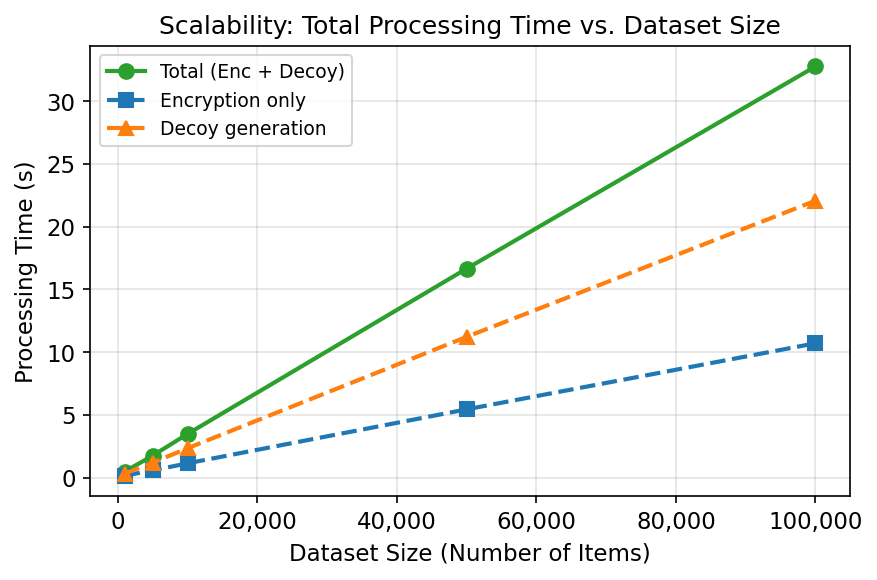

Saved: scalability.png


In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Ns, total_times, color=COLOR_TOTAL, marker='o', label='Total (Enc + Decoy)')
ax.plot(Ns, enc_times,   color=COLOR_ENC,   marker='s', linestyle='--', label='Encryption only')
ax.plot(Ns, decoy_times, color=COLOR_DECOY, marker='^', linestyle='--', label='Decoy generation')

ax.set_xlabel('Dataset Size (Number of Items)')
ax.set_ylabel('Processing Time (s)')
ax.set_title('Scalability: Total Processing Time vs. Dataset Size')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('scalability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scalability.png")

## Cell 6 — Figure 2: Encryption time vs N

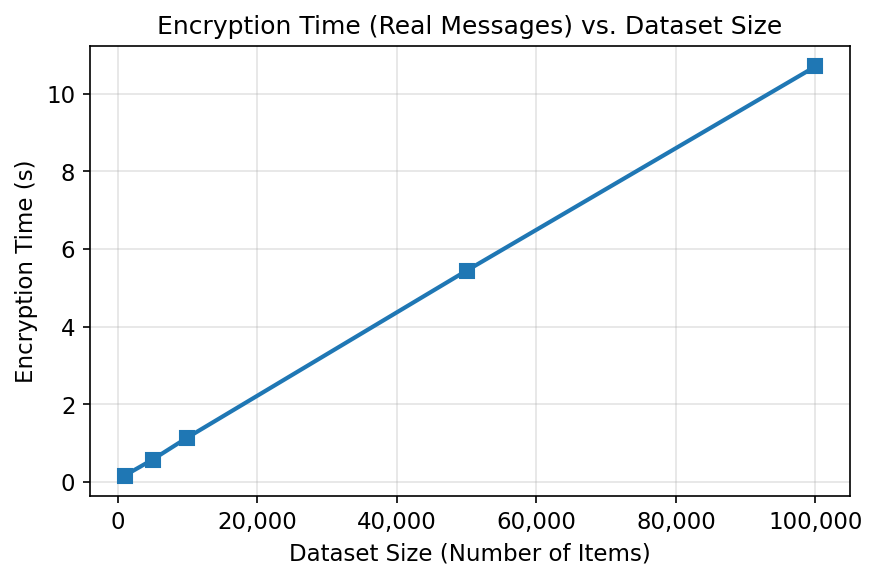

Saved: encryption_time.png


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Ns, enc_times, color=COLOR_ENC, marker='s')

ax.set_xlabel('Dataset Size (Number of Items)')
ax.set_ylabel('Encryption Time (s)')
ax.set_title('Encryption Time (Real Messages) vs. Dataset Size')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('encryption_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: encryption_time.png")

## Cell 7 — Figure 3: Decoy generation time vs N

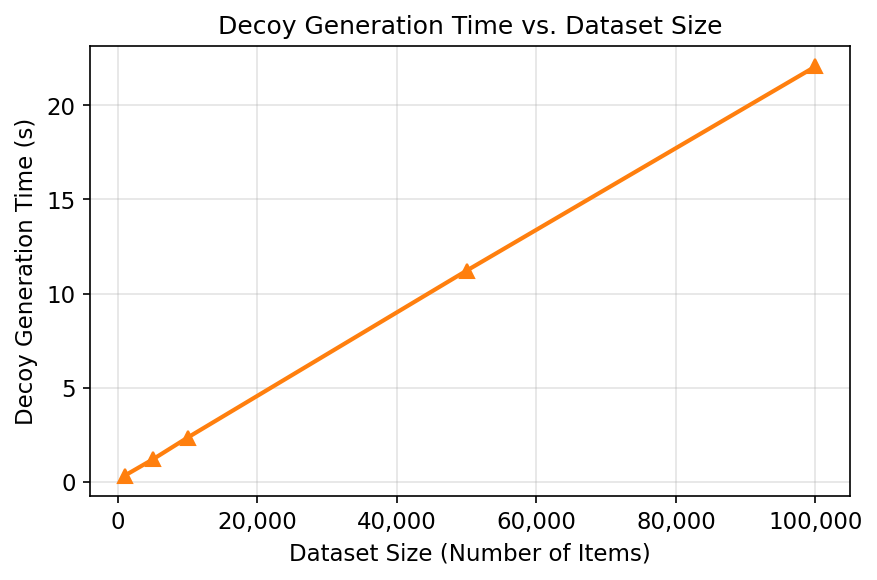

Saved: decoy_time.png


In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Ns, decoy_times, color=COLOR_DECOY, marker='^')

ax.set_xlabel('Dataset Size (Number of Items)')
ax.set_ylabel('Decoy Generation Time (s)')
ax.set_title('Decoy Generation Time vs. Dataset Size')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('decoy_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: decoy_time.png")

## Cell 8 — Figure 4: Storage efficiency (ciphertext length vs N)

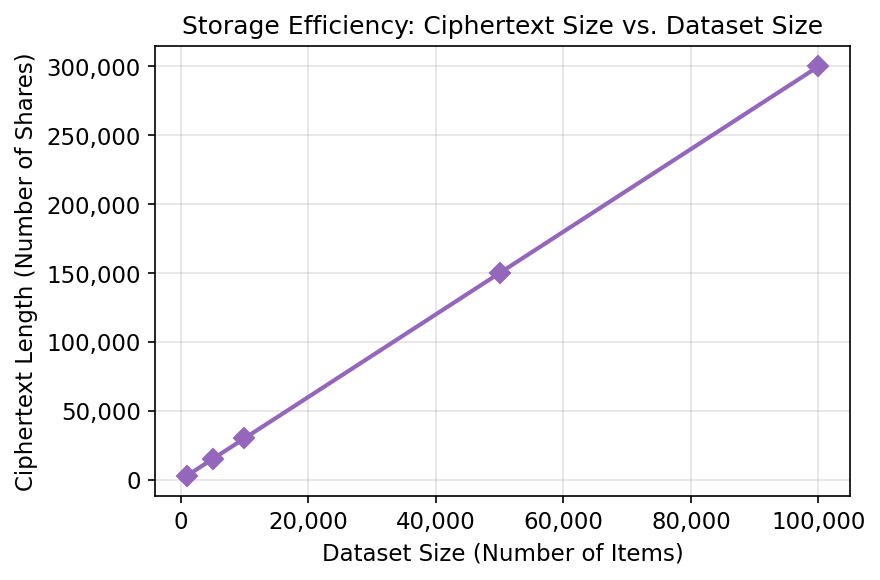

Saved: storage.png


In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Ns, ct_lengths, color=COLOR_STORE, marker='D')

ax.set_xlabel('Dataset Size (Number of Items)')
ax.set_ylabel('Ciphertext Length (Number of Shares)')
ax.set_title('Storage Efficiency: Ciphertext Size vs. Dataset Size')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('storage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: storage.png")

## Cell 9 — Combined 2×2 figure (optional, for slide decks)

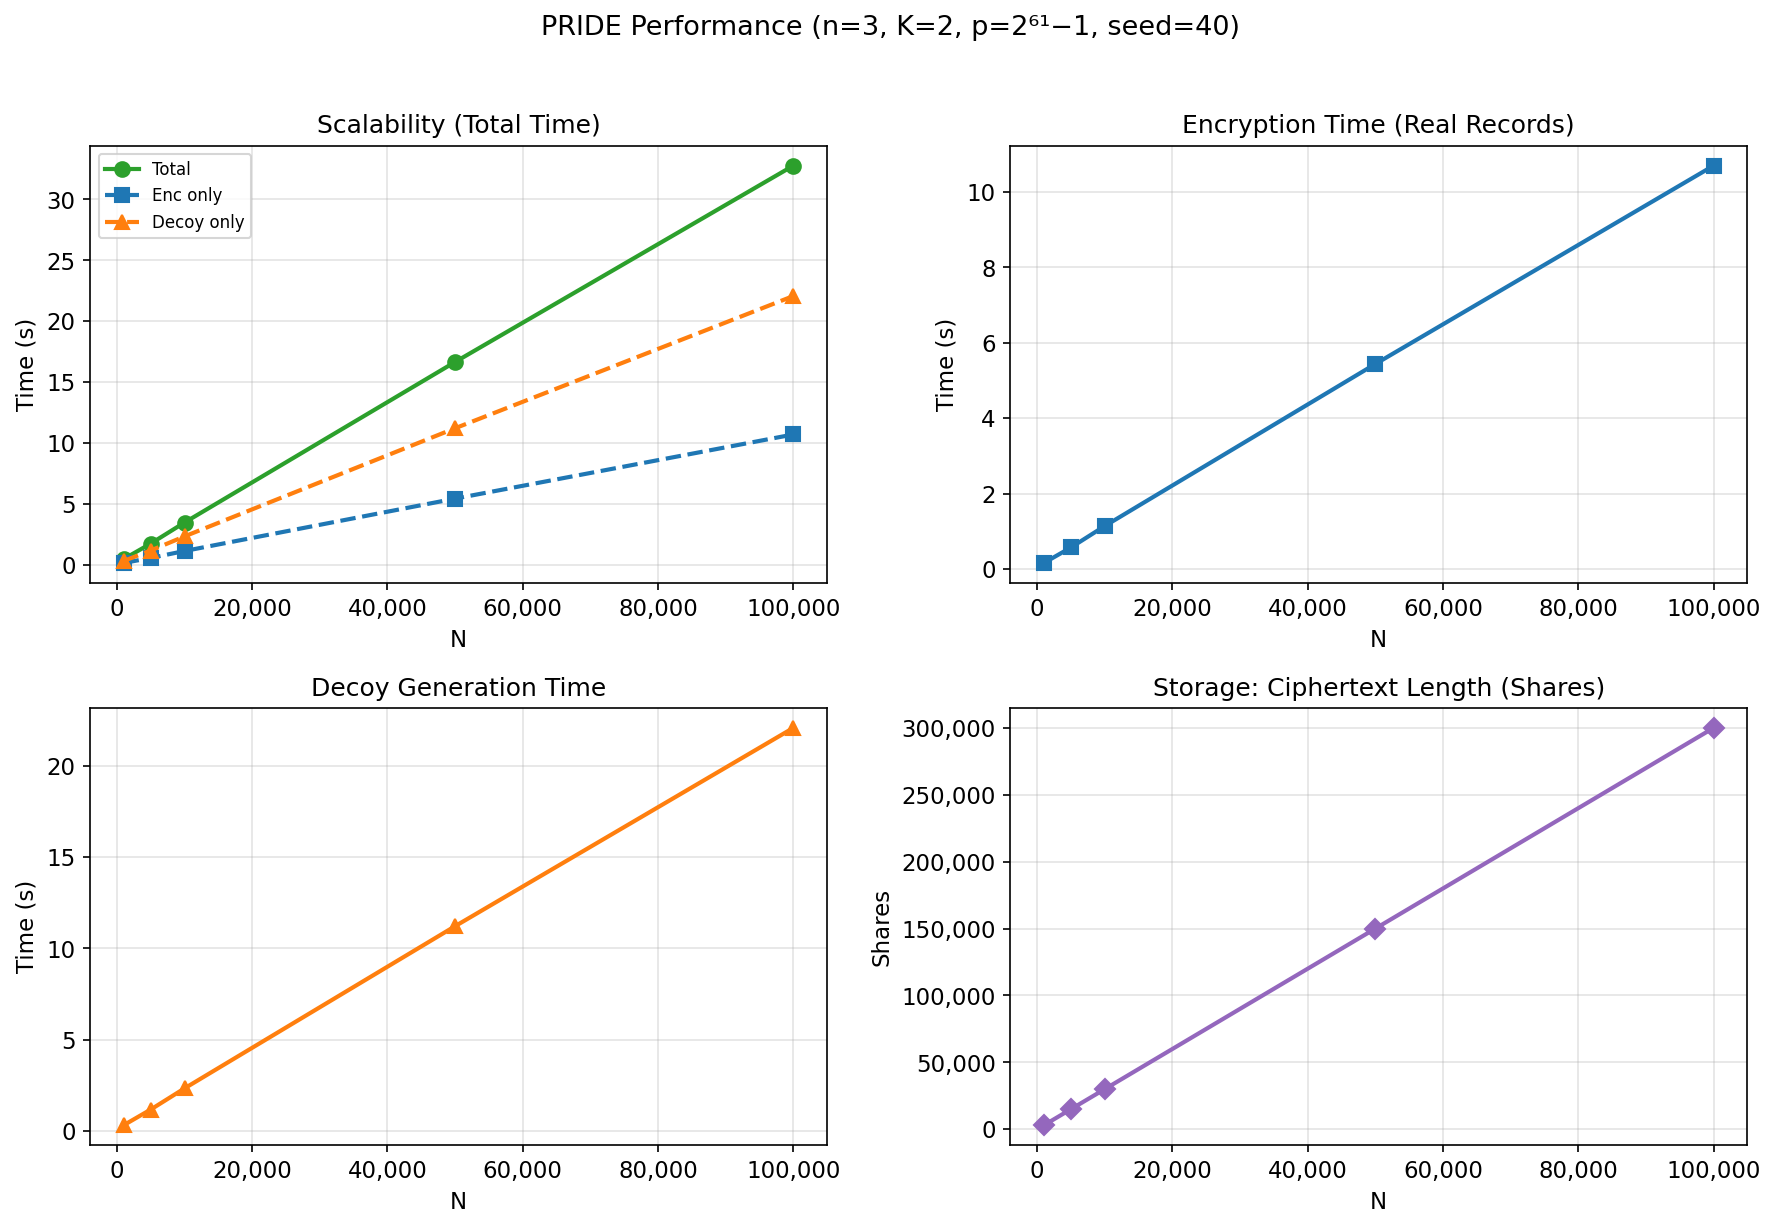

Saved: pride_performance_combined.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: scalability
ax = axes[0, 0]
ax.plot(Ns, total_times, color=COLOR_TOTAL, marker='o', label='Total')
ax.plot(Ns, enc_times,   color=COLOR_ENC,   marker='s', linestyle='--', label='Enc only')
ax.plot(Ns, decoy_times, color=COLOR_DECOY, marker='^', linestyle='--', label='Decoy only')
ax.set_title('Scalability (Total Time)')
ax.set_xlabel('N'); ax.set_ylabel('Time (s)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Top-right: encryption time
ax = axes[0, 1]
ax.plot(Ns, enc_times, color=COLOR_ENC, marker='s')
ax.set_title('Encryption Time (Real Records)')
ax.set_xlabel('N'); ax.set_ylabel('Time (s)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Bottom-left: decoy time
ax = axes[1, 0]
ax.plot(Ns, decoy_times, color=COLOR_DECOY, marker='^')
ax.set_title('Decoy Generation Time')
ax.set_xlabel('N'); ax.set_ylabel('Time (s)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Bottom-right: storage
ax = axes[1, 1]
ax.plot(Ns, ct_lengths, color=COLOR_STORE, marker='D')
ax.set_title('Storage: Ciphertext Length (Shares)')
ax.set_xlabel('N'); ax.set_ylabel('Shares')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle(
    f'PRIDE Performance (n={N_THR}, K={K_DECOYS}, p=2⁶¹−1, seed={SEED})',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('pride_performance_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pride_performance_combined.png")

## Cell 10 — Sanity checks

In [21]:
print("Sanity checks:")

# 1. Linear scaling: ratio of total times should track ratio of N
for i in range(1, len(results)):
    ratio_N    = results[i]['N'] / results[i-1]['N']
    ratio_time = results[i]['total_time'] / results[i-1]['total_time']
    ok = 0.7 < ratio_time / ratio_N < 1.5   # allow 50% deviation
    print(f"  N {results[i-1]['N']:>7,} → {results[i]['N']:>7,}: "
          f"N-ratio={ratio_N:.1f}x, time-ratio={ratio_time:.2f}x  "
          f"[{'OK' if ok else 'CHECK'}]")

# 2. Storage ratio: ct_length / N should be K+1 = 3 (ignoring INIT_SH)
print()
for r in results:
    ratio = (r['ct_length'] - INIT_SH) / r['N']
    ok = abs(ratio - (K_DECOYS + 1)) < 0.01
    print(f"  N={r['N']:>7,}: shares/rec = {ratio:.4f}  "
          f"(expected K+1={K_DECOYS+1})  [{'OK' if ok else 'CHECK'}]")

Sanity checks:
  N   1,000 →   5,000: N-ratio=5.0x, time-ratio=3.65x  [OK]
  N   5,000 →  10,000: N-ratio=2.0x, time-ratio=1.99x  [OK]
  N  10,000 →  50,000: N-ratio=5.0x, time-ratio=4.79x  [OK]
  N  50,000 → 100,000: N-ratio=2.0x, time-ratio=1.97x  [OK]

  N=  1,000: shares/rec = 3.0000  (expected K+1=3)  [OK]
  N=  5,000: shares/rec = 3.0000  (expected K+1=3)  [OK]
  N= 10,000: shares/rec = 3.0000  (expected K+1=3)  [OK]
  N= 50,000: shares/rec = 3.0000  (expected K+1=3)  [OK]
  N=100,000: shares/rec = 3.0000  (expected K+1=3)  [OK]
